In [1]:
"""
test.py — 5-Phase Human-in-the-Loop LangGraph Travel Concierge
================================================================
Phase 0 → orchestrator          → orchestrator_hitl  (interrupt)
Phase 1 → flight / train        → phase1_collector   → phase1_hitl  (interrupt)
Phase 2 → hotel/weather/news    → phase2_collector   → phase2_hitl  (interrupt)
Phase 3 → restaurant/siteseeing → phase3_collector   → phase3_hitl  (interrupt)
Phase 4 → itinerary             → itinerary_hitl     (interrupt)

At every interrupt the user can:
  "yes" / "approve"  → proceed to next phase
  "no"  / "cancel"   → hard stop → END
  <any other text>   → feedback: clear current-phase data, re-run with feedback injected
"""

from __future__ import annotations
import uuid
from langgraph.graph import StateGraph, START, END
from langgraph.constants import Send
from langgraph.types import interrupt
from dotenv import load_dotenv
import langchain
from langchain_cohere import ChatCohere
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

from agents.flight import flight_agent
from agents.hotel import hotel_agent
from agents.itinerary import itinerary_agent
from agents.road import road_agent
from agents.news import news_agent
from agents.orchestrator import TripState, orchestrator_node
from agents.restaurant import restaurant_agent
from agents.site_seeing import site_seeing_agent
from agents.train import train_agent
from agents.weather import weather_agent

load_dotenv()
langchain.debug = False   # flip to True for verbose LLM tracing


/var/folders/gd/bx_mxgsx2x98yvhg30cdrhhc0000gn/T/ipykernel_5246/3745322006.py:19: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [2]:



# ─────────────────────────────────────────────────────────────────────────────
# Helper: normalise a user decision string
# ─────────────────────────────────────────────────────────────────────────────
_APPROVE = {"yes", "y", "approve", "ok", "proceed", "continue", ""}
_CANCEL  = {"no", "n", "cancel", "stop", "quit", "exit", "decline"}

def _classify(decision: str) -> str:
    d = str(decision).strip().lower()
    if d in _APPROVE:
        return "approved"
    if d in _CANCEL:
        return "cancelled"
    return "feedback"


class FeedbackDecision(BaseModel):
    route: Literal["proceed", "retry", "orchestrator", "stop"] = Field(
        description="What to do next based on user feedback."
    )
    rationale: str = Field(description="Short explanation for logging")


def _decide_feedback(phase: str, state: TripState) -> FeedbackDecision:
    """Use an LLM to decide whether to proceed, retry same phase, go back to orchestrator, or stop."""
    llm = ChatCohere(model="command-r-08-2024", temperature=0, max_retries=1)
    structured = llm.with_structured_output(FeedbackDecision)

    data = state.get("scraped_data", {}) or {}
    summary = {
        "flights": len(data.get("flights", []) or []),
        "trains": len(data.get("trains", []) or []),
        "hotels": len(data.get("hotels", []) or []),
        "weather": len(data.get("weather", []) or []),
        "news": len(data.get("news", []) or []),
        "restaurants": len(data.get("restaurants", []) or []),
        "sites": len(data.get("sites", []) or []),
    }

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """You are the routing brain of a multi-phase travel planning graph.

You receive HUMAN FEEDBACK at a phase gate. Decide what should happen next:
- proceed: continue to next phase WITHOUT using the feedback further
- retry: re-run the SAME phase and APPLY the feedback (store it in human_feedback)
- orchestrator: go back to orchestrator to rebuild the plan using the feedback
- stop: end the graph if the user clearly wants to cancel/quit

Guidelines:
- If the user asks for changes to goals/preferences (e.g. destination, dates, budget, mode of travel), choose orchestrator.
- If the user asks to refine results within the same phase (cheaper flights, different hotel vibe), choose retry.
- If the user is satisfied / says continue, choose proceed.
- If the user clearly wants to cancel the whole trip, choose stop.

Return ONLY the structured output.""",
        ),
        (
            "human",
            "Phase: {phase}\nUser request: {user_request}\nLast approved: {last_approved_phase}\nFeedback: {pending_feedback}\nAvailable results summary: {summary}",
        ),
    ])

    return (prompt | structured).invoke({
        "phase": phase,
        "user_request": state.get("user_request", ""),
        "last_approved_phase": state.get("last_approved_phase", ""),
        "pending_feedback": state.get("pending_feedback", ""),
        "summary": summary,
    })


# ─────────────────────────────────────────────────────────────────────────────
# Fan-out helpers  (reused by both initial routing and feedback re-routing)
# ─────────────────────────────────────────────────────────────────────────────
def _phase1_sends(state):
    required = state.get("required_agents", [])
    tasks    = state.get("agent_tasks", {})
    trip     = state.get("trip_details", {})
    hf       = state.get("human_feedback", "")
    sends = [
        Send(ag, {"agent_tasks": {ag: tasks.get(ag, {})}, "trip_details": trip, "human_feedback": hf})
        for ag in ["flight_agent", "train_agent"] if ag in required
    ]
    return sends if sends else "skip_phase1"


def _phase2_sends(state):
    required = state.get("required_agents", [])
    tasks    = state.get("agent_tasks", {})
    trip     = state.get("trip_details", {})
    hf       = state.get("human_feedback", "")
    sends = [
        Send(ag, {"agent_tasks": {ag: tasks.get(ag, {})}, "trip_details": trip, "human_feedback": hf})
        for ag in ["hotel_agent", "weather_agent", "news_agent"] if ag in required
    ]
    return sends if sends else "skip_phase2"


def _phase3_sends(state):
    required = state.get("required_agents", [])
    tasks    = state.get("agent_tasks", {})
    trip     = state.get("trip_details", {})
    hf       = state.get("human_feedback", "")
    
    sends = []
    if "restaurant_agent" in required:
        sends.append(Send("restaurant_agent", {"agent_tasks": tasks, "trip_details": trip, "scraped_data": state.get("scraped_data"), "human_feedback": hf}))
    
    if "site_seeing_agent" in required:
        sends.append(Send("site_seeing_agent", {"agent_tasks": tasks, "trip_details": trip, "scraped_data": state.get("scraped_data"), "human_feedback": hf}))
    
    return sends if sends else "skip_phase3"


# ─────────────────────────────────────────────────────────────────────────────
# Collector / log nodes
# ─────────────────────────────────────────────────────────────────────────────
def phase1_collector(state):
    print("Phase 1 Collector: Transportation data gathered.")
    tl = [{"id": str(uuid.uuid4()), "from": "phase1_collector", "to": "phase1_hitl", "message": "Collecting flight/train data for review."}]
    return {"status_log": ["Phase 1: Transportation data collected."], "timeline": tl}


def phase2_collector(state):
    print("Phase 2 Collector: Hotel / Weather / News gathered.")
    tl = [{"id": str(uuid.uuid4()), "from": "phase2_collector", "to": "phase2_hitl", "message": "Collecting basecamp data for review."}]
    return {"status_log": ["Phase 2: Basecamp data collected."], "timeline": tl}


def phase3_collector(state):
    print("Phase 3 Collector: Activities data gathered.")
    tl = [{"id": str(uuid.uuid4()), "from": "phase3_collector", "to": "phase3_hitl", "message": "Collecting activities data for review."}]
    return {"status_log": ["Phase 3: Activities data collected."], "timeline": tl}


# ── Skip Nodes ─────────────────────────────────────────────────────────────
def skip_phase1(state):
    print("⏩ Skipping Phase 1: No transport agents required.")
    return {"status_log": ["Phase 1: Bypassed (No transport required)"]}

def skip_phase2(state):
    print("⏩ Skipping Phase 2: No basecamp agents required.")
    return {"status_log": ["Phase 2: Bypassed (No basecamp required)"]}

def skip_phase3(state):
    print("⏩ Skipping Phase 3: No activities agents required.")
    return {"status_log": ["Phase 3: Bypassed (No activities required)"]}


# ─────────────────────────────────────────────────────────────────────────────
# HITL Gate Nodes  (each calls interrupt() — the real LangGraph primitive)
# ─────────────────────────────────────────────────────────────────────────────
def orchestrator_hitl(state: TripState) -> dict:
    """Phase 0 gate: show orchestrator plan, wait for human decision."""
    payload = {
        "phase":           "orchestrator",
        "required_agents": state.get("required_agents", []),
        "agent_tasks":     state.get("agent_tasks", {}),
        "trip_details":    state.get("trip_details", {}),
        "message":         (
            "🧠 Orchestrator has built the execution plan.\n"
            "Type 'yes' to approve, 'no' to cancel, or describe changes you want."
        ),
    }
    decision = interrupt(payload)
    action   = _classify(decision)

    # Record AI's message and Human's response
    new_msgs = [
        {"role": "assistant", "content": payload["message"]},
        {"role": "user", "content": str(decision)}
    ]

    if action == "approved":
        return {"hitl_action": "approved", "last_approved_phase": "orchestrator", "human_feedback": "", "messages": new_msgs}
    elif action == "cancelled":
        return {"hitl_action": "cancelled", "feedback_route": "stop", "messages": new_msgs}
    else:
        print(f"💬 Orchestrator feedback received: {decision}")
        return {
            "hitl_action":      "feedback",
            "pending_feedback": str(decision),
            "messages":         new_msgs
        }


def phase1_hitl(state: TripState) -> dict:
    """Phase 1 gate: show transport results, wait for human decision."""
    data = state.get("scraped_data", {})
    payload = {
        "phase":   "transport",
        "flights": data.get("flights", []),
        "trains":  data.get("trains",  []),
        "message": (
            "✈️🚆 Phase 1 complete — Transportation options above.\n"
            "Type 'yes' to approve, 'no' to cancel, or give feedback to refine."
        ),
    }
    decision = interrupt(payload)
    action   = _classify(decision)

    # Record AI's message and Human's response
    new_msgs = [
        {"role": "assistant", "content": payload["message"]},
        {"role": "user", "content": str(decision)}
    ]

    if action == "approved":
        return {"hitl_action": "approved", "last_approved_phase": "transport", "human_feedback": "", "messages": new_msgs}
    elif action == "cancelled":
        return {"hitl_action": "cancelled", "feedback_route": "stop", "messages": new_msgs}
    else:
        print(f"💬 Phase-1 feedback: {decision}")
        return {
            "hitl_action":  "feedback",
            "pending_feedback": str(decision),
            "messages":         new_msgs
        }


def phase2_hitl(state: TripState) -> dict:
    """Phase 2 gate: show hotel/weather/news, wait for human decision."""
    data = state.get("scraped_data", {})
    payload = {
        "phase":   "basecamp",
        "hotels":  data.get("hotels",  []),
        "weather": data.get("weather", []),
        "news":    data.get("news",    []),
        "message": (
            "🏨🌦📰 Phase 2 complete — Hotel, Weather & News above.\n"
            "Type 'yes' to approve, 'no' to cancel, or give feedback to refine."
        ),
    }
    decision = interrupt(payload)
    action   = _classify(decision)

    # Record AI's message and Human's response
    new_msgs = [
        {"role": "assistant", "content": payload["message"]},
        {"role": "user", "content": str(decision)}
    ]

    if action == "approved":
        return {"hitl_action": "approved", "last_approved_phase": "basecamp", "human_feedback": "", "messages": new_msgs}
    elif action == "cancelled":
        return {"hitl_action": "cancelled", "feedback_route": "stop", "messages": new_msgs}
    else:
        print(f"💬 Phase-2 feedback: {decision}")
        return {
            "hitl_action":      "feedback",
            "pending_feedback": str(decision),
            "messages":         new_msgs
        }


def phase3_hitl(state: TripState) -> dict:
    """Phase 3 gate: show restaurant/sightseeing, wait for human decision."""
    data = state.get("scraped_data", {})
    payload = {
        "phase":       "activities",
        "restaurants": data.get("restaurants", []),
        "sightseeing": data.get("sites", []),
        "message": (
            "🍴🏛 Phase 3 complete — Dining & Sightseeing above.\n"
            "Type 'yes' to approve, 'no' to cancel, or give feedback to refine."
        ),
    }
    decision = interrupt(payload)
    action   = _classify(decision)

    # Record AI's message and Human's response
    new_msgs = [
        {"role": "assistant", "content": payload["message"]},
        {"role": "user", "content": str(decision)}
    ]

    if action == "approved":
        return {"hitl_action": "approved", "last_approved_phase": "activities", "human_feedback": "", "messages": new_msgs}
    elif action == "cancelled":
        return {"hitl_action": "cancelled", "feedback_route": "stop", "messages": new_msgs}
    else:
        print(f"💬 Phase-3 feedback: {decision}")
        return {
            "hitl_action":      "feedback",
            "pending_feedback": str(decision),
            "messages":         new_msgs
        }


def itinerary_hitl(state: TripState) -> dict:
    """Phase 4 gate: show final itinerary, give last chance to refine."""
    payload = {
        "phase":     "itinerary",
        "itinerary": state.get("final_itinerary", ""),
        "message": (
            "🗺 Phase 4 complete — Final Itinerary above.\n"
            "Type 'yes' to confirm & finish, 'no' to discard, or give feedback to regenerate."
        ),
    }
    decision = interrupt(payload)
    action   = _classify(decision)

    # Record AI's message and Human's response
    new_msgs = [
        {"role": "assistant", "content": payload["message"]},
        {"role": "user", "content": str(decision)}
    ]

    if action == "approved":
        return {"hitl_action": "approved", "last_approved_phase": "itinerary", "human_feedback": "", "messages": new_msgs}
    elif action == "cancelled":
        return {"hitl_action": "cancelled", "feedback_route": "stop", "messages": new_msgs}
    else:
        print(f"💬 Itinerary feedback: {decision}")
        return {"hitl_action": "feedback", "pending_feedback": str(decision), "messages": new_msgs}


def orchestrator_feedback(state: TripState) -> dict:
    d = _decide_feedback("orchestrator", state)
    route = d.route
    fb = state.get("pending_feedback", "")
    tl = [{"id": str(uuid.uuid4()), "from": "orchestrator_hitl", "to": "orchestrator" if route in {"retry", "orchestrator"} else "phase1_collector", "message": f"Feedback: {d.rationale}"}]
    if route in {"retry", "orchestrator"}:
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "agent_tasks": None,
            "required_agents": None,
            "status_log": [f"Feedback routing({route}): {d.rationale}"],
            "timeline": tl,
        }
    return {
        "feedback_route": route,
        "human_feedback": "",
        "pending_feedback": "",
        "status_log": [f"Feedback routing({route}): {d.rationale}"],
        "timeline": tl,
    }


def phase1_feedback(state: TripState) -> dict:
    d = _decide_feedback("transport", state)
    route = d.route
    fb = state.get("pending_feedback", "")
    to_node = "orchestrator" if route == "orchestrator" else "flight_agent" if route == "retry" else "hotel_agent"
    tl = [{"id": str(uuid.uuid4()), "from": "phase1_hitl", "to": to_node, "message": f"Feedback: {d.rationale}"}]
    if route == "retry":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "scraped_data": {"flights": None, "trains": None},
            "status_log": [f"Feedback routing(retry phase1): {d.rationale}"],
            "timeline": tl,
        }
    if route == "orchestrator":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "agent_tasks": None,
            "required_agents": None,
            "scraped_data": {"flights": None, "trains": None},
            "status_log": [f"Feedback routing(back to orchestrator): {d.rationale}"],
            "timeline": tl,
        }
    return {
        "feedback_route": route,
        "human_feedback": "",
        "pending_feedback": "",
        "status_log": [f"Feedback routing({route}): {d.rationale}"],
        "timeline": tl,
    }


def phase2_feedback(state: TripState) -> dict:
    d = _decide_feedback("basecamp", state)
    route = d.route
    fb = state.get("pending_feedback", "")
    to_node = "orchestrator" if route == "orchestrator" else "hotel_agent" if route == "retry" else "restaurant_agent"
    tl = [{"id": str(uuid.uuid4()), "from": "phase2_hitl", "to": to_node, "message": f"Feedback: {d.rationale}"}]
    if route == "retry":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "scraped_data": {"hotels": None, "weather": None, "news": None},
            "status_log": [f"Feedback routing(retry phase2): {d.rationale}"],
            "timeline": tl,
        }
    if route == "orchestrator":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "agent_tasks": None,
            "required_agents": None,
            "scraped_data": {"hotels": None, "weather": None, "news": None},
            "status_log": [f"Feedback routing(back to orchestrator): {d.rationale}"],
            "timeline": tl,
        }
    return {
        "feedback_route": route,
        "human_feedback": "",
        "pending_feedback": "",
        "status_log": [f"Feedback routing({route}): {d.rationale}"],
        "timeline": tl,
    }


def phase3_feedback(state: TripState) -> dict:
    d = _decide_feedback("activities", state)
    route = d.route
    fb = state.get("pending_feedback", "")
    to_node = "orchestrator" if route == "orchestrator" else "restaurant_agent" if route == "retry" else "itinerary_agent"
    tl = [{"id": str(uuid.uuid4()), "from": "phase3_hitl", "to": to_node, "message": f"Feedback: {d.rationale}"}]
    if route == "retry":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "scraped_data": {"restaurants": None, "sites": None},
            "status_log": [f"Feedback routing(retry phase3): {d.rationale}"],
            "timeline": tl,
        }
    if route == "orchestrator":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "agent_tasks": None,
            "required_agents": None,
            "scraped_data": {"restaurants": None, "sites": None},
            "status_log": [f"Feedback routing(back to orchestrator): {d.rationale}"],
            "timeline": tl,
        }
    return {
        "feedback_route": route,
        "human_feedback": "",
        "pending_feedback": "",
        "status_log": [f"Feedback routing({route}): {d.rationale}"],
        "timeline": tl,
    }


def itinerary_feedback(state: TripState) -> dict:
    d = _decide_feedback("itinerary", state)
    route = d.route
    fb = state.get("pending_feedback", "")
    to_node = "orchestrator" if route == "orchestrator" else "itinerary_agent"
    tl = [{"id": str(uuid.uuid4()), "from": "itinerary_hitl", "to": to_node, "message": f"Feedback: {d.rationale}"}]
    if route == "retry":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "final_itinerary": "",
            "status_log": [f"Feedback routing(retry itinerary): {d.rationale}"],
            "timeline": tl,
        }
    if route == "orchestrator":
        return {
            "feedback_route": route,
            "human_feedback": fb,
            "pending_feedback": "",
            "agent_tasks": None,
            "required_agents": None,
            "final_itinerary": "",
            "status_log": [f"Feedback routing(back to orchestrator): {d.rationale}"],
            "timeline": tl,
        }
    return {
        "feedback_route": route,
        "human_feedback": "",
        "pending_feedback": "",
        "status_log": [f"Feedback routing({route}): {d.rationale}"],
        "timeline": tl,
    }

# ─────────────────────────────────────────────────────────────────────────────

# Conditional-edge routing functions
# ─────────────────────────────────────────────────────────────────────────────
def route_orchestrator_hitl(state):
    action = state.get("hitl_action", "approved")
    if action == "cancelled":
        return END
    if action == "feedback":
        return "orchestrator_feedback"
    return _phase1_sends(state)         # approved → fan-out phase 1


def route_phase1_hitl(state):
    action = state.get("hitl_action", "approved")
    if action == "cancelled":
        return END
    if action == "feedback":
        return "phase1_feedback"
    return _phase2_sends(state)         # approved → fan-out phase 2


def route_phase2_hitl(state):
    action = state.get("hitl_action", "approved")
    if action == "cancelled":
        return END
    if action == "feedback":
        return "phase2_feedback"
    print("DEBUG: Phase 2 Approved. Proceeding to Phase 3 Fan-out.")
    return _phase3_sends(state)


def route_phase3_hitl(state):
    action = state.get("hitl_action", "approved")
    if action == "cancelled":
        return END
    if action == "feedback":
        return "phase3_feedback"
    return "itinerary_agent"            # approved → itinerary


def route_itinerary_hitl(state):
    action = state.get("hitl_action", "approved")
    if action == "cancelled":
        return END
    if action == "feedback":
        return "itinerary_feedback"
    return END                          # approved → done


def route_orchestrator_feedback(state):
    r = state.get("feedback_route", "stop")
    if r == "stop":
        return END
    if r == "orchestrator":
        return "orchestrator"
    if r == "retry":
        return "orchestrator"
    return _phase1_sends(state)


def route_phase1_feedback(state):
    r = state.get("feedback_route", "stop")
    if r == "stop":
        return END
    if r == "orchestrator":
        return "orchestrator"
    if r == "retry":
        return _phase1_sends(state)
    return _phase2_sends(state)


def route_phase2_feedback(state):
    r = state.get("feedback_route", "stop")
    if r == "stop":
        return END
    if r == "orchestrator":
        return "orchestrator"
    if r == "retry":
        return _phase2_sends(state)
    return _phase3_sends(state)


def route_phase3_feedback(state):
    r = state.get("feedback_route", "stop")
    if r == "stop":
        return END
    if r == "orchestrator":
        return "orchestrator"
    if r == "retry":
        return _phase3_sends(state)
    return "itinerary_agent"


def route_itinerary_feedback(state):
    r = state.get("feedback_route", "stop")
    if r == "stop":
        return END
    if r == "orchestrator":
        return "orchestrator"
    if r == "retry":
        return "itinerary_agent"
    return END



In [3]:



# ─────────────────────────────────────────────────────────────────────────────
# Graph construction
# ─────────────────────────────────────────────────────────────────────────────
_ALL_NODES = [
    "orchestrator", "orchestrator_hitl",
    "orchestrator_feedback",
    "flight_agent", "train_agent", "phase1_collector", "phase1_hitl",
    "phase1_feedback",
    "hotel_agent", "weather_agent", "news_agent", "phase2_collector", "phase2_hitl",
    "phase2_feedback",
    "restaurant_agent", "site_seeing_agent", "phase3_collector", "phase3_hitl",
    "phase3_feedback",
    "itinerary_agent", "itinerary_hitl",
    "itinerary_feedback",
    "road_agent",
    "skip_phase1", "skip_phase2", "skip_phase3"
]



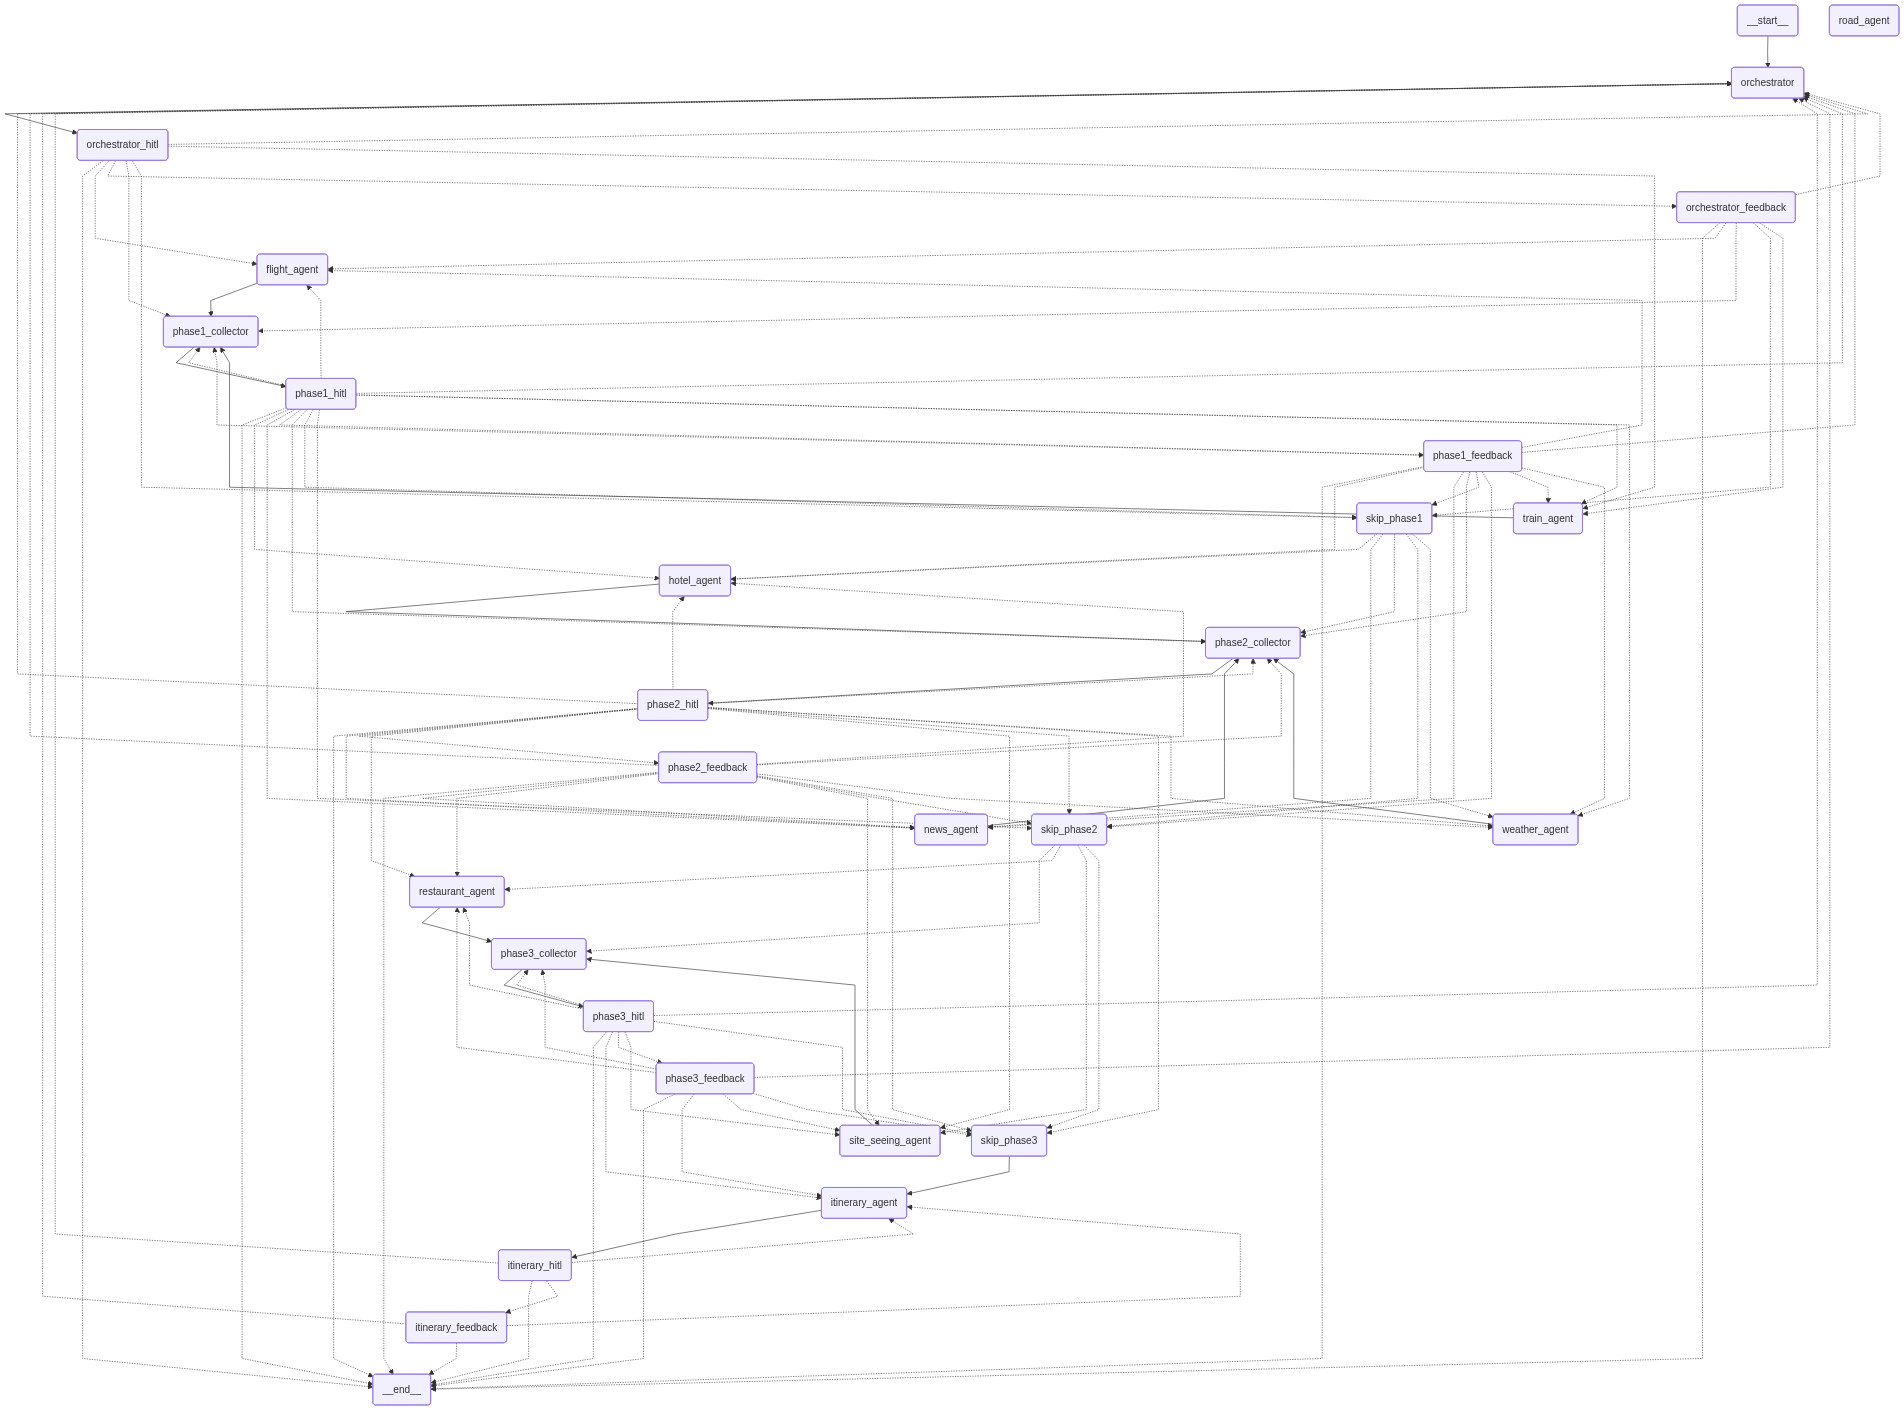

In [6]:


workflow = StateGraph(TripState)

# ── register nodes ────────────────────────────────────────────────────────────
workflow.add_node("orchestrator",       orchestrator_node)
workflow.add_node("orchestrator_hitl",  orchestrator_hitl)
workflow.add_node("orchestrator_feedback", orchestrator_feedback)

workflow.add_node("flight_agent",       flight_agent)
workflow.add_node("train_agent",        train_agent)
workflow.add_node("phase1_collector",   phase1_collector)
workflow.add_node("phase1_hitl",        phase1_hitl)
workflow.add_node("phase1_feedback",    phase1_feedback)

workflow.add_node("hotel_agent",        hotel_agent)
workflow.add_node("weather_agent",      weather_agent)
workflow.add_node("news_agent",         news_agent)
workflow.add_node("phase2_collector",   phase2_collector)
workflow.add_node("phase2_hitl",        phase2_hitl)
workflow.add_node("phase2_feedback",    phase2_feedback)

workflow.add_node("restaurant_agent",   restaurant_agent)
workflow.add_node("site_seeing_agent",  site_seeing_agent)
workflow.add_node("phase3_collector",   phase3_collector)
workflow.add_node("phase3_hitl",        phase3_hitl)
workflow.add_node("phase3_feedback",    phase3_feedback)

workflow.add_node("itinerary_agent",    itinerary_agent)
workflow.add_node("itinerary_hitl",     itinerary_hitl)
workflow.add_node("itinerary_feedback", itinerary_feedback)
workflow.add_node("road_agent",         road_agent)
workflow.add_node("skip_phase1",        skip_phase1)
workflow.add_node("skip_phase2",        skip_phase2)
workflow.add_node("skip_phase3",        skip_phase3)

# ── edges ─────────────────────────────────────────────────────────────────────
workflow.add_edge(START, "orchestrator")
workflow.add_edge("orchestrator", "orchestrator_hitl")

workflow.add_conditional_edges(
    "orchestrator_hitl", route_orchestrator_hitl,
    ["orchestrator_feedback", "orchestrator", "flight_agent", "train_agent", "phase1_collector", "skip_phase1", END],
)

workflow.add_conditional_edges(
    "orchestrator_feedback", route_orchestrator_feedback,
    ["orchestrator", "flight_agent", "train_agent", "phase1_collector", "skip_phase1", END],
)

workflow.add_edge("flight_agent",     "phase1_collector")
workflow.add_edge("train_agent",      "phase1_collector")
workflow.add_edge("phase1_collector", "phase1_hitl")

workflow.add_conditional_edges(
    "phase1_hitl", route_phase1_hitl,
    ["phase1_feedback", "flight_agent", "train_agent", "phase1_collector", "hotel_agent", "weather_agent", "news_agent", "phase2_collector", "orchestrator", "skip_phase1", "skip_phase2", END],
)

workflow.add_conditional_edges(
    "phase1_feedback", route_phase1_feedback,
    ["orchestrator", "flight_agent", "train_agent", "phase1_collector", "hotel_agent", "weather_agent", "news_agent", "phase2_collector", "skip_phase1", "skip_phase2", END],
)

workflow.add_edge("hotel_agent",      "phase2_collector")
workflow.add_edge("weather_agent",    "phase2_collector")
workflow.add_edge("news_agent",       "phase2_collector")
workflow.add_edge("phase2_collector", "phase2_hitl")

workflow.add_conditional_edges(
    "phase2_hitl", route_phase2_hitl,
    ["phase2_feedback", "hotel_agent", "weather_agent", "news_agent", "phase2_collector", "restaurant_agent", "site_seeing_agent", "orchestrator", "skip_phase2", "skip_phase3", END],
)

workflow.add_conditional_edges(
    "phase2_feedback", route_phase2_feedback,
    ["orchestrator", "hotel_agent", "weather_agent", "news_agent", "phase2_collector", "restaurant_agent", "site_seeing_agent", "skip_phase2", "skip_phase3", END],
)

workflow.add_edge("restaurant_agent",  "phase3_collector")
workflow.add_edge("site_seeing_agent", "phase3_collector")
workflow.add_edge("phase3_collector",  "phase3_hitl")

workflow.add_conditional_edges(
    "phase3_hitl", route_phase3_hitl,
    ["phase3_feedback", "restaurant_agent", "site_seeing_agent", "phase3_collector", "itinerary_agent", "orchestrator", "skip_phase3", END],
)

workflow.add_conditional_edges(
    "phase3_feedback", route_phase3_feedback,
    ["orchestrator", "restaurant_agent", "site_seeing_agent", "phase3_collector", "itinerary_agent", "skip_phase3", END],
)

workflow.add_edge("itinerary_agent", "itinerary_hitl")

workflow.add_conditional_edges(
    "itinerary_hitl", route_itinerary_hitl,
    ["itinerary_feedback", "itinerary_agent", "orchestrator", END],
)

workflow.add_conditional_edges(
    "itinerary_feedback", route_itinerary_feedback,
    ["orchestrator", "itinerary_agent", END],
)

# ── Add edges from Skip nodes to the start of the next phase ──────────────────
workflow.add_conditional_edges("skip_phase1", _phase2_sends, ["hotel_agent", "weather_agent", "news_agent", "phase2_collector", "skip_phase2"])
workflow.add_conditional_edges("skip_phase2", _phase3_sends, ["restaurant_agent", "site_seeing_agent", "phase3_collector", "skip_phase3"])
workflow.add_edge("skip_phase3", "itinerary_agent")

wk = workflow.compile()

wk

# ─────────────────────────────────────────────────────────────────────────────
# Export
# # ─────────────────────────────────────────────────────────────────────────────
# def get_compiled_graph(checkpointer):
#     """Compile the workflow with the given checkpointer. No interrupt_before needed."""
#     wk = workflow.compile(checkpointer=checkpointer)
    
#     return wk


# print("5-Phase HITL StateGraph builder ready!")
